In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RANDOM_STATE=42

rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['axes.grid'] = True

In [3]:
# y = wTx + b = ∑ wj xj + b

x = np.array([2.0, -1.0, 0.5])
w = np.array([1.5, -2.0, 4.0])

b = 0.7

contributions = w * x
y_hat = w @ x + b

summary = pd.DataFrame(
    {
        "feature value x_j": x,
        "weight w_j": w,
        "contributions w_j x x_j": contributions,
    },
    index=[r"$j=1$", r"$j=2$", r"$j=3$"],
)
display(summary)

print(f"Sum of weighted feature contributions ∑wjxj= {contributions.sum():.3f}")
print(f"Bias b = {b:.3f}")
print(f"Prediction y_hat = {y_hat:.3f}")

x_aug = np.r_[x, 1.0]
w_aug = np.r_[w, b]
print(f'Augmented dot-product check = {w_aug @ x_aug:.3f}')


,feature value x_j,weight w_j,contributions w_j x x_j
$j=1$,2.0,1.5,3.0
$j=2$,-1.0,-2.0,2.0
$j=3$,0.5,4.0,2.0


Sum of weighted feature contributions ∑wjxj= 7.000
Bias b = 0.700
Prediction y_hat = 7.700
Augmented dot-product check = 7.700


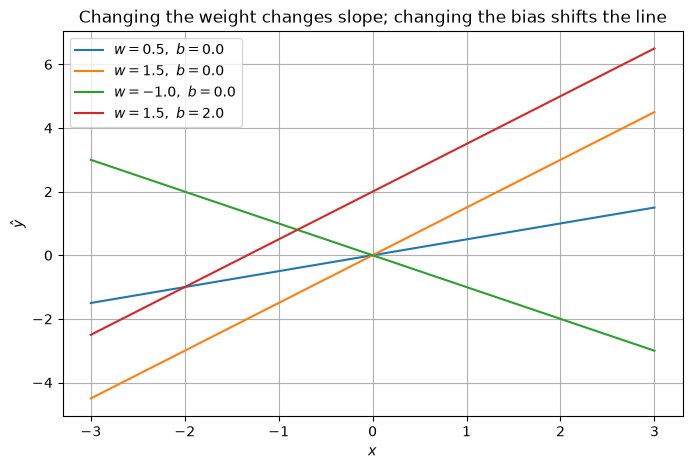

In [4]:
x_grid = np.linspace(-3, 3, 200)
settings = [
    (0.5, 0.0),
    (1.5, 0.0),
    (-1.0, 0.0),
    (1.5, 2.0),
]

fig, ax = plt.subplots(figsize=(8, 5))
for w_scalar, b_scalar in settings:
    ax.plot(
        x_grid,
        w_scalar * x_grid + b_scalar,
        label=rf"$w={w_scalar},\ b={b_scalar}$",
    )
ax.set_xlabel("$x$")
ax.set_ylabel(r"$\hat y$")
ax.set_title("Changing the weight changes slope; changing the bias shifts the line")
ax.legend()
plt.show()


In [5]:
# Linear model for multiple outputs

x = np.array([1.2, -0.7, 2.0])
W = np.array([
    [0.8, -0.2, 1.0, 0.3],
    [1.5, 0.6, -0.4, -1.1],
    [-0.5, 1.3, 0.2, 0.7],
])

b = np.array([0.1, -0.4, 0.0, 0.8])

y_vec = W.T @ x + b

print('x shape: ',x.shape)
print('W shape: ',W.shape)
print('b shape: ',b.shape)
print('output shape: ',y_vec.shape)
print("output: ", y_vec)

x shape:  (3,)
W shape:  (3, 4)
b shape:  (4,)
output shape:  (4,)
output:  [-0.99  1.54  1.88  3.33]


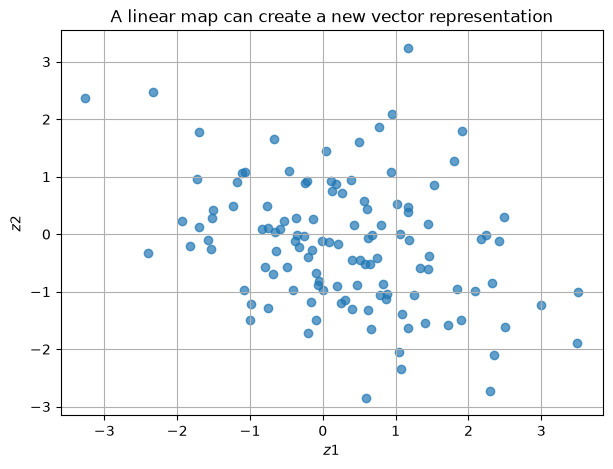

In [6]:
# map a 3D input to a 2D embedding

X3 = rng.normal(size=(120,3))
W_embed = np.array([[1.0, 0.2],[-0.5,1.1],[0.8,-0.4]])
b_embed = np.array([0.3, -0.2])

Z2 = X3 @ W_embed + b_embed

plt.scatter(Z2[:,0], Z2[:,1], alpha=0.7)
plt.xlabel('$z1$')
plt.ylabel('$z2$')
plt.title('A linear map can create a new vector representation')
plt.show()


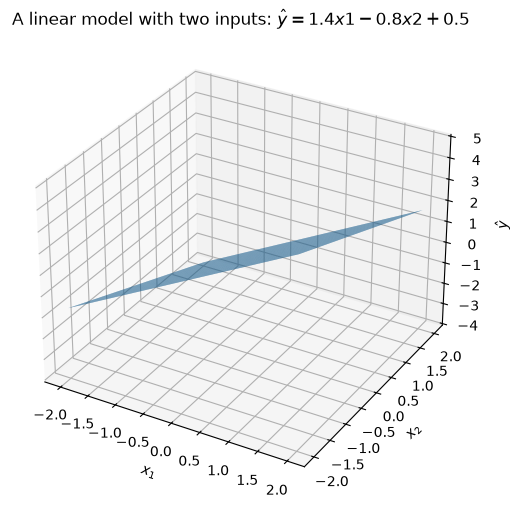

In [7]:
# A 2D linear model gives a plane in (x1, x2, y)-space.

x1 = np.linspace(-2, 2, 35)
x2 = np.linspace(-2, 2, 35)

X1, X2 = np.meshgrid(x1, x2)
Y = 1.4 * X1 - 0.8 * X2 + 0.5

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Y, alpha=0.75)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel(r"$\hat y$")
ax.set_title(r'A linear model with two inputs: $\hat y = 1.4x1 -0.8x2 + 0.5$')
plt.show()

In [8]:
# Linear model on non-linear features

def polynomial_features(x, degree=3):
    x = np.asarray(x)
    return np.column_stack(
        [x**p for p in range(1, degree+1)] #x + xˆ2 + Xˆ3 + ... + xˆp
    )

x = np.array([-2.0, -1.0, 0.5, 2.0])
phi = polynomial_features(x, degree=3)

display(pd.DataFrame(phi, index=x, columns=['x', 'xˆ2', 'xˆ3']))


,x,xˆ2,xˆ3
-2.0,-2.0,4.00,-8.000
-1.0,-1.0,1.00,-1.000
0.5,0.5,0.25,0.125
2.0,2.0,4.00,8.000


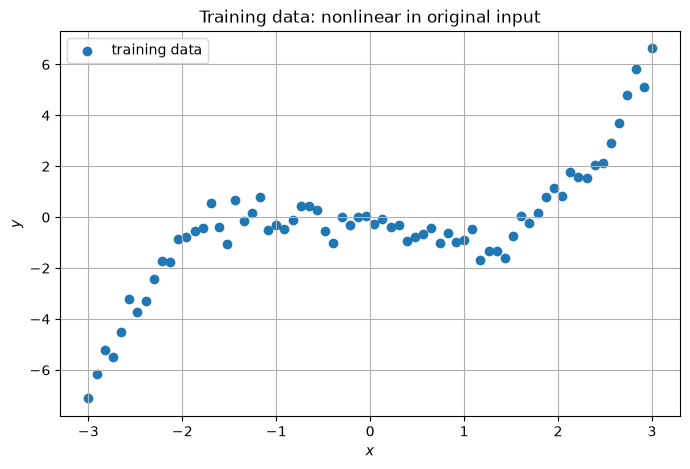

In [9]:
N = 70

x_train = np.linspace(-3, 3, N)

true_y = 0.35 * x_train**3 - 0.9 * x_train - 0.3
noise = rng.normal(0,0.45,size=N)
y_train = true_y + noise

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(x_train, y_train, label='training data')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title("Training data: nonlinear in original input")
ax.legend()
plt.show()



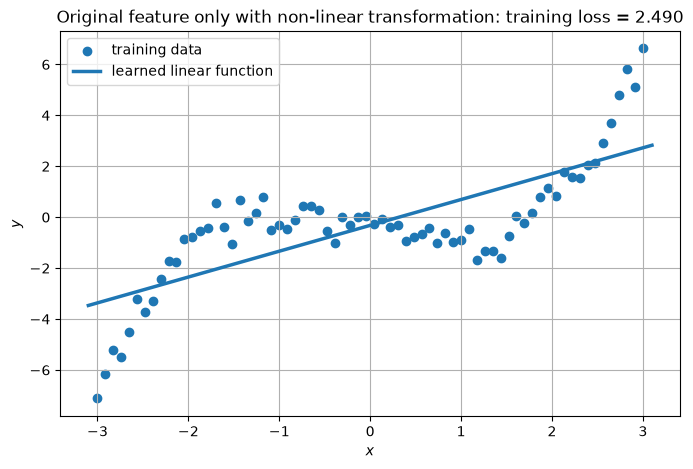

Learned w = 1.015, b = -0.321


In [10]:
def fit_linear_model_gd(X, y, learning_rate = 0.01, iterations=2000, snapshots=()):
    X = np.asarray(X)
    y = np.asarray(y)

    if X.ndim == 1:
        X = X[:,None] #broadcasting

    n, d = X.shape
    w = np.zeros(d) # zero initialization
    b = 0.0
    history = []
    snapshots = set(snapshots)

    for t in range(iterations):
        pred = X@w + b
        residual = pred - y
        loss = np.mean(residual**2)
        grad_w = (2/n) * (X.T @ residual)
        grad_b = 2 * residual.mean()

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

        if t in snapshots or t == iterations -1:
            history.append((t+1, w.copy(), float(b), float(loss)))

    final_pred = X @ w + b
    final_loss = np.mean((final_pred - y)**2)
    return w, b, final_loss, history

X_original= x_train[:,None]
w_lin, b_lin, loss_lin, _ = fit_linear_model_gd(
    X_original, y_train, learning_rate=0.03, iterations=2000
)

x_plot = np.linspace(-3.1, 3.1, 300)

y_plot_lin = w_lin[0] * x_plot + b_lin

fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(x_train, y_train, label="training data")
ax.plot(x_plot, y_plot_lin, linewidth=2.5, label="learned linear function")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(f"Original feature only with non-linear transformation: training loss = {loss_lin:.3f}")
ax.legend()
plt.show()

print(f"Learned w = {w_lin[0]:.3f}, b = {b_lin:.3f}")

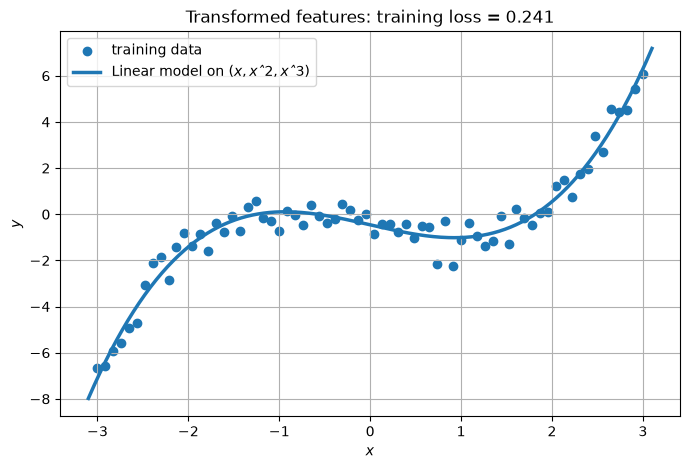

Weights in the standardized polynomial-feature representation
[-1.59   0.018  3.713]
b = -0.441


,model,number of learned weights,training loss
0,Linear in original feature $x$,1,2.443614
1,"Linear in transformed features $[x,x^2,x^3]$",3,0.240746


In [32]:
# Linear model with transformed features

phi_train = polynomial_features(x_train, degree=3)
phi_std = phi_train.std(axis=0)
phi_mean = phi_train.mean(axis=0)
phi_train_scaled =  (phi_train - phi_mean)/ phi_std

w_poly, b_poly, loss_poly, _ = fit_linear_model_gd(
    phi_train_scaled, y_train, learning_rate=0.3, iterations=5000
)

phi_plot = polynomial_features(x_plot, degree=3)
phi_plot_scaled= (phi_plot - phi_mean)/phi_std
y_plot_poly = phi_plot_scaled @ w_poly + b_poly

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(x_train, y_train, label='training data')
ax.plot(x_plot, y_plot_poly, linewidth=2.5, label=r'Linear model on $(x, xˆ2, xˆ3)$')
ax.set_xlabel('$x$')
ax.set_ylabel("$y$")
ax.set_title(f'Transformed features: training loss = {loss_poly:.3f}')
ax.legend()
plt.show()

print('Weights in the standardized polynomial-feature representation')
print(np.round(w_poly, 3))
print(f'b = {b_poly:.3f}')

comparison = pd.DataFrame(
    {
        "model": [
            r"Linear in original feature $x$",
            r"Linear in transformed features $[x,x^2,x^3]$",
        ],
        "number of learned weights": [1, 3],
        "training loss": [loss_lin, loss_poly],
    }
)
display(comparison)
             

In [11]:
# Quantifying and Optimizing the loss

#residual = yn - yhat_n = yn - (wTxn + b)
# least square loss = 1/N ∑ (yn - (wTxn + b))ˆ2


def predict_linear(X, w, b):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X[:, None]
    return X @ np.asarray(w) + b

def mse_loss(y, y_hat):
    y = np.asarray(y)
    y_hat = np.asarray(y_hat)
    return np.mean((y-y_hat)**2)

y_hat_train_lin = predict_linear(X_original, w_lin, b_lin)

residuals = y_train - y_hat_train_lin

residual_table = pd.DataFrame(
    {
        'x': x_train[:8],
        'target y': y_train[:8],
        'prediction y_hat': y_hat_train_lin[:8],
        'residual y - y_hat': residuals[:8],
        'squared residuals': residuals[:8]**2,
    }
)
display(residual_table.round(3))
print('Mean of all squared residuals=', round(mse_loss(y_train, y_hat_train_lin),4))

,x,target y,prediction y_hat,residual y - y_hat,squared residuals
0,-3.000,-7.119,-3.366,-3.753,14.082
1,-2.913,-6.158,-3.278,-2.880,8.293
2,-2.826,-5.207,-3.189,-2.017,4.069
3,-2.739,-5.504,-3.101,-2.403,5.774
4,-2.652,-4.499,-3.013,-1.486,2.207
5,-2.565,-3.233,-2.925,-0.308,0.095
6,-2.478,-3.732,-2.836,-0.895,0.801
7,-2.391,-3.304,-2.748,-0.556,0.309


Mean of all squared residuals= 2.4896


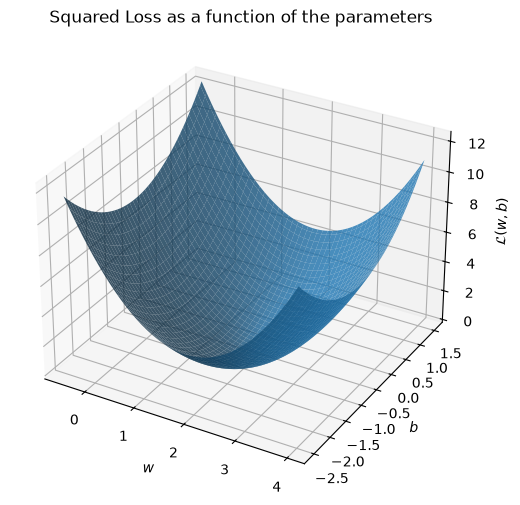

In [13]:
# squared loss visualization

X_loss = np.linspace(-2,2,30)
y_loss = 1.8*X_loss - 0.6 + rng.normal(0,0.25, size=len(X_loss))

w_values = np.linspace(-0.5, 4.0, 90)
b_values = np.linspace(-2.5, 1.5, 90)
W_grid, B_grid = np.meshgrid(w_values, b_values)
L_grid = np.empty_like(W_grid)

for i in range(B_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        pred = W_grid[i,j] * X_loss + B_grid[i,j]
        L_grid[i,j] = np.mean((y_loss - pred)**2)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W_grid, B_grid, L_grid, alpha=0.8)
ax.set_xlabel('$w$')
ax.set_ylabel('$b$')
ax.set_zlabel(r'$\mathcal{L}(w,b)$')
ax.set_title("Squared Loss as a function of the parameters")
plt.show()

In [15]:
# Iterative optimization

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

X_loss = X_loss[:, None]
iterations_linear = 50  # Keep the number of iterations as it is
snapshot_steps = list(range(iterations_linear))  # Capture every iteration
_, _, _, history = fit_linear_model_gd(
    X_loss,
    y_loss,
    learning_rate=0.04,
    iterations=iterations_linear,
    snapshots=snapshot_steps,
)

rows = []
for iteration, w_now, b_now, loss_now in history:
    rows.append(
        {
            "iteration": iteration,
            "w": w_now[0],
            "b": b_now,
            "training MSE": loss_now,
        }
    )


# Visualize how the fitted line changes at selected iterations as an animation.
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_loss, y_loss, s=25, label="training data", alpha=0.6)
(line,) = ax.plot([], [], linewidth=2.5, color="red", label="current model")

ax.set_title("Progression of Linear Model Fit Over Iterations")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.grid(True)
ax.set_xlim(X_loss.min() - 0.5, X_loss.max() + 0.5)
ax.set_ylim(y_loss.min() - 0.5, y_loss.max() + 0.5)
ax.legend()


def update(frame):
    iteration, w_now, b_now, loss_now = history[frame]
    y_predicted = w_now[0] * X_loss + b_now
    line.set_data(X_loss, y_predicted)
    ax.set_title(
        f"Iteration {iteration}, w={w_now[0]:.3f}, b={b_now:.3f}, Loss={loss_now:.3f}"
    )  # Updated title
    return (line,)


animation = FuncAnimation(fig, update, frames=len(history), interval=100, blit=True)
plt.close(fig)  # Prevent static plot from showing
HTML(animation.to_jshtml())

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

Phi_train = polynomial_features(x_train, degree=3)

# Standardizing the transformed columns makes this black-box GD demo numerically easier.
phi_mean = Phi_train.mean(axis=0)
phi_std = Phi_train.std(axis=0)
Phi_train_scaled = (Phi_train - phi_mean) / phi_std

iterations_poly = 1000
snapshot_steps_poly = list(range(0, iterations_poly, 25)) + [
    iterations_poly - 1
]  # Show every 25 iterations
_, _, _, history_poly = fit_linear_model_gd(
    Phi_train_scaled,
    y_train,
    learning_rate=0.03,
    iterations=iterations_poly,
    snapshots=snapshot_steps_poly,
)

rows_poly = []
for iteration, w_now, b_now, loss_now in history_poly:
    rows_poly.append(
        {
            "iteration": iteration,
            "w": w_now,
            "b": b_now,
            "training MSE": loss_now,
        }
    )

# Visualize how the fitted curve changes at selected iterations as an animation.
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_train, y_train, s=25, label="training data", alpha=0.6)

x_plot_poly = np.linspace(x_train.min(), x_train.max(), 300)
(line_poly,) = ax.plot([], [], linewidth=2.5, color="red", label="current model")

ax.set_title("Progression of Polynomial Model Fit Over Iterations")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.grid(True)
ax.set_xlim(x_train.min() - 0.5, x_train.max() + 0.5)
ax.set_ylim(y_train.min() - 0.5, y_train.max() + 0.5)
ax.legend()


def update_poly(frame):
    iteration, w_now, b_now, loss_now = history_poly[frame]
    Phi_plot_iter = polynomial_features(x_plot_poly, degree=3)
    Phi_plot_iter_scaled = (Phi_plot_iter - phi_mean) / phi_std
    y_predicted_poly = Phi_plot_iter_scaled @ w_now + b_now
    ax.set_title(
        f"Iteration {iteration}, w={np.round(w_now, 3)}, b={b_now:.3f}, Loss={loss_now:.3f}"
    )  # Updated title
    line_poly.set_data(x_plot_poly, y_predicted_poly)
    return (line_poly,)


animation_poly = FuncAnimation(
    fig, update_poly, frames=len(history_poly), interval=100, blit=True
)
plt.close(fig)  # Prevent static plot from showing
HTML(animation_poly.to_jshtml())
